## **Nomes:**
**Kauã de Oliveira Ribeiro**  
**Lívia Vilela Ribeiro Guimarães**  
**João Gabriel Ferreira Ribeiro**  

## **BER teórica das diferentes modulações digitais**

Um dos parâmetros mais importantes para avaliar o desempenho de sistemas de comunicação digital é a taxa de erro de bit, denominada BER (*Bit Error Rate*). Essa grandeza representa a probabilidade de um bit ser detectado incorretamente na recepção.

Em canais AWGN (*Additive White Gaussian Noise*), é possível analisar a BER teórica em função da relação entre a energia média por bit e a densidade espectral de potência do ruído:

$$
\frac{E_b}{N_0}
$$

As expressões de probabilidade de erro são frequentemente escritas utilizando a função $Q(x)$, definida como a probabilidade de uma variável aleatória gaussiana padronizada exceder determinado valor. Entretanto, em simulações computacionais, é comum utilizar a função complementar do erro, `erfc()`, disponível diretamente em bibliotecas matemáticas do Python. A relação entre essas funções é dada por:

$$
Q(x)=
\frac{1}{2}
\operatorname{erfc}
\left(
\frac{x}{\sqrt{2}}
\right)
$$

Outro aspecto importante das modulações digitais multiníveis é a influência do número de símbolos da constelação, representado por $M$. Cada símbolo transporta k bits de informação:

$$
k=\log_2(M)
$$

O aumento de $M$ permite transmitir mais bits por símbolo, o que consequentemente aumenta a eficiência espectral, permitindo transmitir mais informação em uma mesma largura de banda. Entretanto, seus efeitos dependem da família de modulação analisada. Nas modulações M-PSK e M-QAM, a elevação de $M$ normalmente reduz a separação entre os símbolos, aumentando a sensibilidade ao ruído. Na M-FSK ortogonal, o aumento de $M$ pode melhorar a eficiência de potência, mas exige maior largura de banda.

---

### **Modulação M-PSK**

Na modulação M-PSK (*M-ary Phase Shift Keying*), a informação é transmitida utilizando $M$ fases distintas. O aumento de $M$ reduz a separação angular entre símbolos vizinhos, tornando o sistema mais sensível ao ruído.

Para codificação Gray, $M \geq 4$ e valores elevados de $E_b/N_0$, a BER pode ser aproximada por:

$$
P_b
\approx
\frac{2}{\log_2(M)}
Q
\left(
\sqrt{
2\log_2(M)
\frac{E_b}{N_0}
}
\sin
\left(
\frac{\pi}{M}
\right)
\right)
$$

Utilizando `erfc()`:

$$
P_b
\approx
\frac{1}{\log_2(M)}
\operatorname{erfc}
\left(
\sqrt{
\log_2(M)
\frac{E_b}{N_0}
}
\sin
\left(
\frac{\pi}{M}
\right)
\right)
$$

---

### **Modulação M-QAM com constelação quadrada**

Na modulação M-QAM (*M-ary Quadrature Amplitude Modulation*), os símbolos são representados por diferentes combinações de amplitude e fase. Essa técnica apresenta elevada eficiência espectral e é empregada em diversos sistemas modernos de comunicação.

Quando $k=\log_2(M)$ é par, é possível formar uma constelação quadrada com:

$$
L=\sqrt{M}
$$

níveis em cada eixo. Alguns exemplos são 4-QAM, 16-QAM, 64-QAM e 256-QAM.

Para constelações quadradas com mapeamento Gray e valores elevados de $E_b/N_0$, a BER pode ser aproximada por:

$$
P_b
\approx
\frac{4}{\log_2(M)}
\left(
1-\frac{1}{\sqrt{M}}
\right)
Q
\left(
\sqrt{
\frac{3\log_2(M)}{M-1}
\frac{E_b}{N_0}
}
\right)
$$

Utilizando `erfc()`:

$$
P_b
\approx
\frac{2}{\log_2(M)}
\left(
1-\frac{1}{\sqrt{M}}
\right)
\operatorname{erfc}
\left(
\sqrt{
\frac{3\log_2(M)}
{2(M-1)}
\frac{E_b}{N_0}
}
\right)
$$

---

### **Modulação M-QAM com constelação não quadrada**

Quando $k=\log_2(M)$ é ímpar, não é possível dividir igualmente os bits entre os eixos em fase e em quadratura. Consequentemente, a constelação não pode ser formada pelo produto cartesiano de duas constelações PAM unidimensionais.

Alguns exemplos são:

$$
8\text{-QAM},\quad
32\text{-QAM},\quad
128\text{-QAM},\quad
512\text{-QAM}
$$

Uma possibilidade consiste em utilizar uma constelação cruzada, também chamada *cross constellation*.

Para constelações M-QAM cruzadas e valores elevados de $E_b/N_0$, a probabilidade de erro de símbolo pode ser aproximada por:

$$
P_s
\approx
2
\left(
1-\frac{1}{\sqrt{2M}}
\right)
\operatorname{erfc}
\left(
\sqrt{
\frac{
96\log_2(M)
}{
62M-64
}
\frac{E_b}{N_0}
}
\right)
$$

Diferentemente do caso quadrado, não é possível garantir mapeamento Gray completo entre todos os símbolos vizinhos mais próximos. Portanto, a BER não é exatamente igual à SER dividida pela quantidade de bits por símbolo. Para constelações cruzadas:

$$
P_b >
\frac{P_s}{\log_2(M)}
$$

Ainda assim, a expressão:

$$
P_{b,\text{ref}}
=\frac{P_s}{\log_2(M)}
$$

pode ser utilizada como uma curva de referência inferior para comparação com a BER simulada:

$$
P_{b,\text{ref}}
\approx
\frac{2}{\log_2(M)}
\left(
1-\frac{1}{\sqrt{2M}}
\right)
\operatorname{erfc}
\left(
\sqrt{
\frac{
96\log_2(M)
}{
62M-64
}
\frac{E_b}{N_0}
}
\right)
$$

Uma estimativa mais precisa da BER depende da geometria da constelação e do mapeamento entre os grupos de bits e os símbolos.

---

### **Modulação M-FSK coerente**

Na modulação M-FSK (*M-ary Frequency Shift Keying*), cada símbolo é associado a uma frequência distinta. O aumento do número de frequências pode melhorar a imunidade ao ruído, mas exige maior largura de banda.

Para sinais ortogonais com detecção coerente em canais AWGN, a probabilidade de erro de símbolo pode ser aproximada por:

$$
P_s
\approx
(M-1)
Q
\left(
\sqrt{
\log_2(M)
\frac{E_b}{N_0}
}
\right)
$$

Utilizando `erfc()`:

$$
P_s
\approx
\frac{M-1}{2}
\operatorname{erfc}
\left(
\sqrt{
\frac{
\log_2(M)
}{2}
\frac{E_b}{N_0}
}
\right)
$$

Para a M-FSK ortogonal, a relação entre BER e SER é dada por:

$$
P_b=
\frac{M}{2(M-1)}
P_s
$$

Portanto:

$$
P_b
\approx
\frac{M}{4}
\operatorname{erfc}
\left(
\sqrt{
\frac{
\log_2(M)
}{2}
\frac{E_b}{N_0}
}
\right)
$$

Nesse caso, a relação independe do mapeamento entre os símbolos e os bits, pois a distância euclidiana é a mesma entre todos os pares de símbolos ortogonais.

Em todos os casos, a substituição da função $Q(x)$ pela função `erfc()` permite implementar diretamente as expressões teóricas em Python, simplificando o cálculo das curvas e a comparação com os resultados simulados.

**Referências**

[1] Guimarães, D. A.; Souza, R. A. A. *Transmissão Digital: Princípios e Aplicações*. São Paulo: Editora Érica, 2014.

[2] Guimarães, D. A. *Digital Transmission: A Simulation-Aided Introduction with VisSim/Comm*. Springer, 2010.

In [11]:
# =================================
# 1. IMPORTAÇÃO DE BIBLIOTECAS
# =================================

# Usada para manipulação de vetores de bits, matrizes, operações lógicas e matemáticas
import numpy as np
# random: Gerador de números pseudoaleatórios
import random
# Usada para a criação de gráficos e visualização de dados (curvas BER vs Eb/N0)
import matplotlib.pyplot as plt
# Essencial para calcular analiticamente a BER teórica das modulações em canais AWGN
# erfc: Função complementar do erro (Error Function Complementary)
from scipy.special import erfc

In [12]:
# ======================================================
# 2. FUNÇÕES AUXILIARES DE CONVERSÃO (BIT/DECIMAL/GRAY)
# ======================================================

# Converte um array de inteiros codificados em Gray para inteiros binários puros
# O mapeamento Gray garante que símbolos vizinhos variem em apenas 1 bit,
# minimizando a BER em caso de detecção incorreta do símbolo adjacente
def gray_to_binary(gray):
    binary = gray.copy()
    shift = 1

    while True:
        # Desloca os bits para a direita a fim de realizar a operação XOR em cascata
        shifted = binary >> shift
        # Se todos os bits deslocados forem zero, a conversão chegou ao fim
        if np.all(shifted == 0):
            break
        # Operação XOR acumulada para recuperar o padrão binário original
        binary = binary ^ shifted
        # Dobra o passo do deslocamento
        shift <<= 1

    return binary


# Converte uma matriz de grupos de 'k' bits em seus respectivos valores decimais
# Cada linha da matriz representa um símbolo contendo 'k' bits
def bits_to_decimal(bits_grouped):
    # Identifica quantos bits existem por símbolo (número de colunas)
    k = bits_grouped.shape[1]
    # Cria os pesos binários correspondentes a cada posição de bit
    weights = 1 << np.arange(k - 1, -1, -1)
    # Realiza o produto escalar entre a matriz de bits e os pesos para obter o decimal
    return bits_grouped.dot(weights)


# Converte um vetor de valores decimais de volta para uma matriz de bits de largura 'k'
# Utilizada na recepção para demapear os símbolos recuperados em bits de informação
def decimal_to_bits(decimal_values, k):
    return (
        # Realiza uma máscara de bits (AND lógico) para extrair cada posição binária
        ((decimal_values[:, None] & (1 << np.arange(k - 1, -1, -1))) > 0)
        # Converte o resultado booleano (True/False) em inteiro (1/0)
        .astype(int)
    )

In [13]:
# =======================================================
# 3. CONFIGURAÇÃO DOS PARÂMETROS GLOBAIS DA SIMULAÇÃO
# =======================================================

# Lista com as ordens de modulação (M) que serão avaliadas
M_list = [2, 4, 8, 16, 32, 64]
# Quantidade total de bits a serem transmitidos na simulação
N_bits = 10000000                 # Um valor alto (10 milhões) garante precisão estatística para estimar taxas de erro baixas
# Vetor com o intervalo da relação Energia de Bit por Densidade de Ruído (Eb/N0) em dB
EbN0dB_range = np.arange(0, 30)   # Vai de 0 dB até 29 dB, incrementando de 1 em 1 dB
# Armazena a quantidade de pontos que serão calculados na curva (20 pontos)
itr = len(EbN0dB_range)

# Inicialização de dicionários vazios para armazenar as curvas de BER para cada M
# Curvas Teóricas (calculadas por fórmulas):
ber_psk_theo_all = {}
ber_qam_theo_all = {}
ber_fsk_theo_all = {}

# Curvas Simuladas (obtidas via contagem de erros):
ber_psk_sim_all = {}
ber_qam_sim_all = {}
ber_fsk_sim_all = {}

In [14]:
# ===============================================================
# 4. MAPEAMENTO DE CORES PARA IDENTIFICAÇÃO DE 'M' NOS GRÁFICOS
# ===============================================================

# Carrega o mapa de cores padrão "tab10" do matplotlib para garantir bom contraste visual
cmap_M = plt.get_cmap("tab10")

# Cria um dicionário vinculando cada ordem M a uma cor fixa
# Isso garante que a curva M=16, por exemplo, use exatamente a mesma cor
# nos gráficos de PSK, QAM e FSK, facilitando a comparação visual
cores_M = {
    M: cmap_M(indice)
    for indice, M in enumerate(M_list)
}

In [15]:
# ===================================================
# 5. FUNÇÕES DE FORMATAÇÃO DE NOMES DAS MODULAÇÕES
# ===================================================

# Retornam strings com a nomenclatura comercial/acadêmica correta
# de acordo com o valor de M (ex: M=2 vira BPSK, M=4 vira QPSK, M=8 vira 8-PSK)
def nome_psk(M):
    return "BPSK" if M == 2 else "QPSK" if M==4 else f"{M}-PSK"

def nome_qam(M):
    return f"{M}-QAM"

def nome_fsk(M):
    return "BFSK" if M == 2 else "QFSK" if M==4 else f"{M}-FSK"

## **Simulação de BER para M-PSK**

BPSK   | Eb/N0 =  0 dB | BER_sim = 7.850630e-02 | BER_teo = 7.864960e-02
BPSK   | Eb/N0 =  1 dB | BER_sim = 5.618470e-02 | BER_teo = 5.628195e-02
BPSK   | Eb/N0 =  2 dB | BER_sim = 3.748280e-02 | BER_teo = 3.750613e-02
BPSK   | Eb/N0 =  3 dB | BER_sim = 2.284360e-02 | BER_teo = 2.287841e-02
BPSK   | Eb/N0 =  4 dB | BER_sim = 1.245030e-02 | BER_teo = 1.250082e-02
BPSK   | Eb/N0 =  5 dB | BER_sim = 5.976000e-03 | BER_teo = 5.953867e-03
BPSK   | Eb/N0 =  6 dB | BER_sim = 2.379900e-03 | BER_teo = 2.388291e-03
BPSK   | Eb/N0 =  7 dB | BER_sim = 7.750000e-04 | BER_teo = 7.726748e-04
BPSK   | Eb/N0 =  8 dB | BER_sim = 1.860000e-04 | BER_teo = 1.909078e-04
BPSK   | Eb/N0 =  9 dB | BER_sim = 3.330000e-05 | BER_teo = 3.362723e-05
BPSK   | Eb/N0 = 10 dB | BER_sim = 4.100000e-06 | BER_teo = 3.872108e-06
BPSK   | Eb/N0 = 11 dB | BER_sim = 5.000000e-07 | BER_teo = 2.613068e-07
BPSK   | Eb/N0 = 12 dB | BER_sim = 0.000000e+00 | BER_teo = 9.006010e-09
BPSK   | Eb/N0 = 13 dB | BER_sim = 0.000000e+00 | B

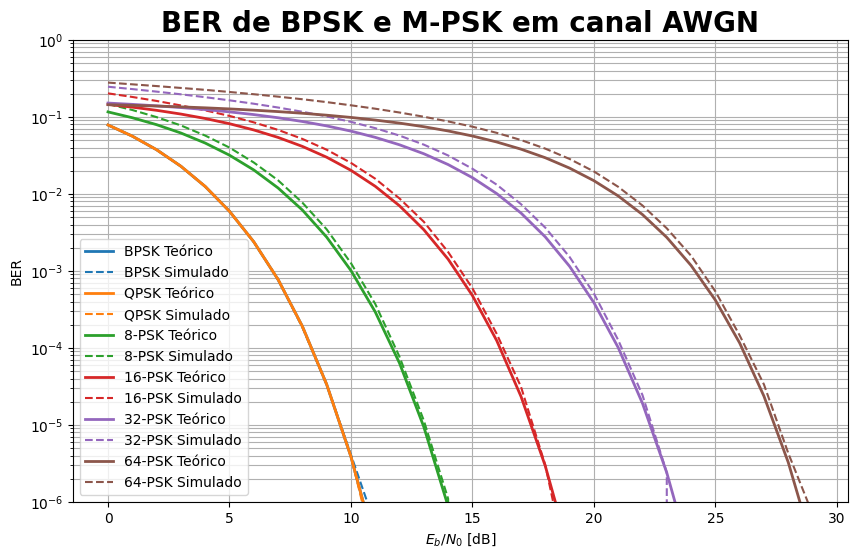

In [16]:
# ==========================================================
# 6. INICIALIZAÇÃO DA FIGURA E ESTRUTURA DO LOOP PRINCIPAL
# ==========================================================

# Inicializa uma nova janela gráfica com dimensões controladas (10x6 polegadas)
plt.figure(figsize=(10, 6))

# Itera sobre cada ordem de modulação definida na lista global (M = 2, 4, 8, 16, 32, 64)
for M in M_list:

    # Representa o número de bits carregados por símbolo
    # Calculado por k = log2(M). Ex: M=4 (QPSK) -> k=2 bits/símbolo
    k = int(np.log2(M))

    # Ajusta o tamanho do vetor dividindo o total de bits pelo número de bits por símbolo
    # O operador '//' realiza a divisão inteira (descarta o resto)
    N_symbols = N_bits // k

    # Reajusta a quantidade exata de bits que serão de fato processados, garantindo que o vetor
    # de bits seja perfeitamente divisível pelo tamanho do símbolo k
    N_bits_real = N_symbols * k

    # Inicializa vetores vazios preenchidos com zeros para acumular as taxas de erro (BER)
    # simuladas e teóricas para cada um dos pontos de Eb/N0 avaliados
    ber_sim = np.zeros(itr)
    ber_theo = np.zeros(itr)

    # Invoca a função auxiliar para obter a string de identificação da modulação (ex: 'BPSK', 'QPSK')
    modulation_name = nome_psk(M)

    # ========================================================================
    # CASO ESPECIAL: MODULAÇÃO BPSK (M = 2)
    # ========================================================================
    # O BPSK é tratado separadamente por ser uma modulação unidimensional (opera apenas em fase),
    # o que permite otimizar o código processando números puramente reais (sem parte complexa/quadratura).
    if M == 2:

        # --------------------------------------------------------------------
        # A) Geração de Dados Aleatórios
        # --------------------------------------------------------------------
        # Cria um vetor contendo bits pseudoaleatórios equiprováveis (0 ou 1) de comprimento N_bits_real
        tx_bits = np.random.randint(
            0,
            2,
            N_bits_real
        )

        # --------------------------------------------------------------------
        # B) Mapeamento Geométrico BPSK (Modulação Constelação)
        # --------------------------------------------------------------------
        # Transforma o domínio lógico de bits {0, 1} no domínio físico de símbolos { -1, +1 }
        # Equação: bit 0 -> 2*(0) - 1 = -1 | bit 1 -> 2*(1) - 1 = +1
        tx_symbols = 2 * tx_bits - 1

        # --------------------------------------------------------------------
        # C) Varredura da Relação Sinal-Ruído (Eb/N0)
        # --------------------------------------------------------------------
        for n, EbN0dB in enumerate(EbN0dB_range):

            # Converte a relação de energia expressa em decibéis (dB) para a escala linear
            # Eb/N0 = 10 ^ (Eb/N0_dB / 10)
            EbN0 = 10 ** (
                EbN0dB / 10
            )

            # --- Dedução do cálculo de Variância do Ruído AWGN Unidimensional ---
            # Como a energia do bit (Eb) é unitária nesta normalização (Eb = 1):
            # A densidade espectral do ruído é: N0 = 1 / (Eb/N0)
            # Para canais reais/unidimensionais, a variância total do ruído é sigma² = N0 / 2
            # Logo, o desvio padrão (raiz quadrada da variância) é calculado abaixo:
            noise_std = 1 / np.sqrt(
                2 * EbN0
            )

            # Gera amostras de Ruído Branco Gaussiano Aditivo (AWGN)
            # np.random.randn gera uma distribuição normal padrão (média=0, variância=1)
            # Multiplicamos pelo desvio-padrão (noise_std) para escalonar o ruído ao nível do canal configurado
            noise = noise_std * np.random.randn(
                N_bits_real
            )

            # Efeito do Canal: Soma linear do ruído AWGN ao sinal transmitido
            rx_symbols = tx_symbols + noise

            # ----------------------------------------------------------------
            # D) Bloco de Decisão (Detector Limiar de Decisão)
            # ----------------------------------------------------------------
            # O receptor de máxima verossimilhança para BPSK analisa o sinal com base no limiar zero
            # Se a amplitude recebida for maior ou igual a zero, decide pelo bit 1, caso contrário, bit 0
            rx_bits = (
                rx_symbols >= 0
            ).astype(int)

            # ----------------------------------------------------------------
            # E) Contagem Estatística de Erros
            # ----------------------------------------------------------------
            # Compara termo a termo os vetores tx_bits e rx_bits, somando as posições divergentes
            bit_errors = np.sum(
                tx_bits != rx_bits
            )

            # A BER simulada corresponde à razão entre os bits errados e o total de bits transmitidos
            ber_sim[n] = (
                bit_errors /
                N_bits_real
            )

            # ----------------------------------------------------------------
            # F) Cálculo da Curva Analítica Teórica
            # ----------------------------------------------------------------
            # Aplica a expressão exata de probabilidade de erro para a modulação BPSK em canais AWGN
            # Fórmula matemática: Pb = 0.5 * erfc( sqrt( Eb/N0 ) )
            ber_theo[n] = 0.5 * erfc(
                np.sqrt(EbN0)
            )

            # Exibe os resultados parciais em tempo real no console de saída
            print(
                f"{modulation_name:6s} | "
                f"Eb/N0 = {EbN0dB:2d} dB | "
                f"BER_sim = {ber_sim[n]:.6e} | "
                f"BER_teo = {ber_theo[n]:.6e}"
            )

    # ========================================================================
    # CASO GERAL: MODULAÇÃO M-PSK MULTINÍVEL (M >= 4)
    # ========================================================================
    # Implementa transmissões bidimensionais (em fase 'I' e quadratura 'Q')
    # mapeando blocos de bits em fases circulares distribuídas geometricamente
    else:

        # --------------------------------------------------------------------
        # A) Geração de Dados e Agrupamento de Símbolos
        # --------------------------------------------------------------------
        # Gera o fluxo binário bruto original
        tx_bits = np.random.randint(
            0,
            2,
            N_bits_real
        )

        # Reorganiza o vetor unidimensional em uma matriz bidimensional onde cada linha
        # representa um slot de símbolo contendo exatamente 'k' bits em suas colunas
        tx_bits_grouped = tx_bits.reshape(
            (N_symbols, k)
        )

        # Converte a palavra binária agrupada em seu correspondente número inteiro decimal
        tx_decimal = bits_to_decimal(
            tx_bits_grouped
        )

        # --------------------------------------------------------------------
        # B) Codificação de Gray (Mapeamento de Proteção)
        # --------------------------------------------------------------------
        # Aplica a operação bitwise XOR (^) entre o valor decimal e ele mesmo deslocado em 1 bit
        # Isso gera o código de Gray, garantindo que símbolos espacialmente adjacentes na constelação
        # diferem em apenas um único bit, reduzindo drasticamente a BER geral
        tx_gray = (
            tx_decimal ^
            (tx_decimal >> 1)
        )

        # --------------------------------------------------------------------
        # C) Construção Geométrica da Constelação M-PSK
        # --------------------------------------------------------------------
        # Define a Energia do Bit (Eb=1) e escala para obter a Energia do Símbolo: Es = k * Eb
        Eb = 1
        Es = k * Eb

        # Aloca espaço de memória para a matriz da constelação de dimensões (M linhas x 2 colunas)
        # Onde a coluna 0 armazena o componente Em-Fase (I) e a coluna 1 a Quadratura (Q)
        constellation = np.zeros(
            (M, 2)
        )

        # Distribui os M símbolos de maneira uniforme ao longo de uma circunferência de raio sqrt(Es)
        for i in range(M):

            # Calcula o argumento angular de cada ponto equidistante i: theta = (2 * pi * i) / M
            theta_i = (
                2 * np.pi * i / M
            )

            # Projeção no eixo Horizontal / Em-Fase (I)
            constellation[i, 0] = (
                np.sqrt(Es) *
                np.cos(theta_i)
            )

            # Projeção no eixo Vertical / Quadratura (Q)
            constellation[i, 1] = (
                np.sqrt(Es) *
                np.sin(theta_i)
            )

        # Mapeamento físico: Usa o índice do vetor codificado em Gray para selecionar
        # as coordenadas (I, Q) correspondentes na matriz geométrica 'constellation'
        tx_symbols = constellation[
            tx_gray
        ]

        # --------------------------------------------------------------------
        # D) Varredura da Relação Sinal-Ruído (Eb/N0) para M-PSK
        # --------------------------------------------------------------------
        for n, EbN0dB in enumerate(EbN0dB_range):

            # Conversão dB -> Linear
            EbN0 = 10 ** (
                EbN0dB / 10
            )

            # Calcula a Densidade de Potência do Ruído: N0 = Eb / (Eb/N0)
            N0 = Eb / EbN0

            # --- Dedução da Variância para Canais Bidimensionais em Quadratura ---
            # Como o ruído AWGN complexo atua de forma independente em ambos os canais (I e Q),
            # a variância total N0 é dividida igualmente entre os eixos.
            # Logo, o desvio-padrão de cada um dos eixos bidimensionais é dado por sqrt(N0 / 2)
            noise_std = np.sqrt(
                N0 / 2
            )

            # Gera uma matriz de ruído gaussiano bidimensional de dimensões (N_symbols x 2 eixos)
            # Multiplicado por noise_std para adequar a variância de ruído em cada dimensão.
            noise = noise_std * np.random.randn(
                N_symbols,
                2
            )

            # Adiciona o ruído bidimensional aos símbolos transmitidos (Modulação + Canal AWGN)
            rx_symbols = (
                tx_symbols +
                noise
            )

            # ----------------------------------------------------------------
            # E) Detector por Critério de Máxima Verossimilhança (ML)
            # ----------------------------------------------------------------
            # Cria uma matriz intermediária para armazenar a distância euclidiana quadrada
            # entre cada símbolo recebido e todos os M pontos teóricos da constelação
            distances = np.zeros(
                (N_symbols, M)
            )

            # Calcula a distância euclidiana para cada hipótese de símbolo i na constelação
            for i in range(M):

                # Calcula d² = (I_recebido - I_teorico)² + (Q_recebido - Q_teorico)²
                distances[:, i] = np.sum(
                    (
                        rx_symbols -
                        constellation[i]
                    ) ** 2,
                    axis=1 # Executa a soma ao longo dos eixos (I e Q)
                )

            # Decisão ML: O receptor escolhe o índice que possui a MENOR distância euclidiana
            # em relação ao ponto amostrado no espaço de fases
            rx_gray = np.argmin(distances, axis=1)

            # ----------------------------------------------------------------
            # F) Processo de Demapeamento e Decodificação de Bits
            # ----------------------------------------------------------------
            # Desfaz a codificação Gray convertendo os inteiros detectados de volta para binário puro
            rx_decimal = gray_to_binary(rx_gray)

            # Descompacta os números decimais inteiros de volta em grupos de 'k' bits
            rx_bits_grouped = decimal_to_bits(rx_decimal, k)

            # Aplica o achatamento da matriz (flatten / reshape -1) para retornar ao formato de vetor contínuo
            rx_bits = rx_bits_grouped.reshape(-1)

            # ----------------------------------------------------------------
            # G) Avaliação da Taxa de Erro de Bit (BER) Simulada
            # ----------------------------------------------------------------
            bit_errors = np.sum(
                tx_bits != rx_bits
            )

            ber_sim[n] = (
                bit_errors /
                N_bits_real
            )

            # ----------------------------------------------------------------
            # H) Cálculo da Curva Analítica Teórica para M-PSK com Código Gray
            # ----------------------------------------------------------------
            # Utiliza a aproximação padrão para alta relação sinal-ruído com codificação Gray
            # Expressão matemática: Pb ≈ (1 / k) * erfc( sqrt( k * Eb/N0 ) * sin( pi / M ) )
            ber_theo[n] = (
                (1 / k) *
                erfc(
                    np.sqrt(k * EbN0) *
                    np.sin(np.pi / M)
                )
            )

            # Log impresso em console
            print(
                f"{modulation_name:6s} | "
                f"Eb/N0 = {EbN0dB:2d} dB | "
                f"BER_sim = {ber_sim[n]:.6e} | "
                f"BER_teo = {ber_theo[n]:.6e}"
            )

    # ========================================================================
    # 7. ARMAZENAMENTO HISTÓRICO DOS DADOS CALCULADOS
    # ========================================================================
    # Salva uma cópia profunda dos vetores calculados nos dicionários globais, usando a ordem M como chave
    ber_psk_theo_all[M] = (
        ber_theo.copy()
    )

    ber_psk_sim_all[M] = (
        ber_sim.copy()
    )

    # ========================================================================
    # 8. CONSTRUÇÃO GRÁFICA DAS CURVAS (PLOTAGEM)
    # ========================================================================
    # Recupera a cor associada unicamente à ordem M atual para padronizar o gráfico
    cor_M = cores_M[M]

    # Plota a curva analítica teórica em linha contínua ("-")
    plt.semilogy(
        EbN0dB_range,
        ber_theo,
        "-",
        color=cor_M,
        linewidth=2,
        label=f"{modulation_name} Teórico"
    )

    # Plota os pontos estatísticos obtidos da simulação de Monte Carlo em linha tracejada ("--")
    plt.semilogy(
        EbN0dB_range,
        ber_sim,
        linestyle="--",
        color=cor_M,
        label=f"{modulation_name} Simulado"
    )


# ============================================================================
# 9. ESTILIZAÇÃO E FORMATAÇÃO FINAL DO GRÁFICO (MATPLOTLIB)
# ============================================================================

# Ativa as grades principais e secundárias, essencial para leitura em escalas logarítmicas
plt.grid(True, which="both")

# Rotula os eixos aplicando a notação matemática padrão
plt.xlabel("$E_b/N_0$ [dB]")
plt.ylabel("BER")

# Define o título principal enfatizando os esquemas sob análise
plt.title("BER de BPSK e M-PSK em canal AWGN", fontsize=20, fontweight="bold")

# Posiciona a legenda explicativa automaticamente de forma a não obstruir os traçados
plt.legend()

# Limita o eixo vertical (Y) para focar na faixa de interesse prático da BER (de 10^-6 até 1)
plt.ylim(1e-6, 1)

# Renderiza o gráfico final na tela
plt.show()

## **Simulação de BER para M-QAM**

2-QAM  | Eb/N0 =  0 dB | BER_sim = 7.858520e-02 | BER_teo = 7.864960e-02
2-QAM  | Eb/N0 =  1 dB | BER_sim = 5.631440e-02 | BER_teo = 5.628195e-02
2-QAM  | Eb/N0 =  2 dB | BER_sim = 3.758170e-02 | BER_teo = 3.750613e-02
2-QAM  | Eb/N0 =  3 dB | BER_sim = 2.285180e-02 | BER_teo = 2.287841e-02
2-QAM  | Eb/N0 =  4 dB | BER_sim = 1.245750e-02 | BER_teo = 1.250082e-02
2-QAM  | Eb/N0 =  5 dB | BER_sim = 5.940900e-03 | BER_teo = 5.953867e-03
2-QAM  | Eb/N0 =  6 dB | BER_sim = 2.377400e-03 | BER_teo = 2.388291e-03
2-QAM  | Eb/N0 =  7 dB | BER_sim = 7.722000e-04 | BER_teo = 7.726748e-04
2-QAM  | Eb/N0 =  8 dB | BER_sim = 1.957000e-04 | BER_teo = 1.909078e-04
2-QAM  | Eb/N0 =  9 dB | BER_sim = 3.610000e-05 | BER_teo = 3.362723e-05
2-QAM  | Eb/N0 = 10 dB | BER_sim = 3.700000e-06 | BER_teo = 3.872108e-06
2-QAM  | Eb/N0 = 11 dB | BER_sim = 4.000000e-07 | BER_teo = 2.613068e-07
2-QAM  | Eb/N0 = 12 dB | BER_sim = 0.000000e+00 | BER_teo = 9.006010e-09
2-QAM  | Eb/N0 = 13 dB | BER_sim = 0.000000e+00 | B

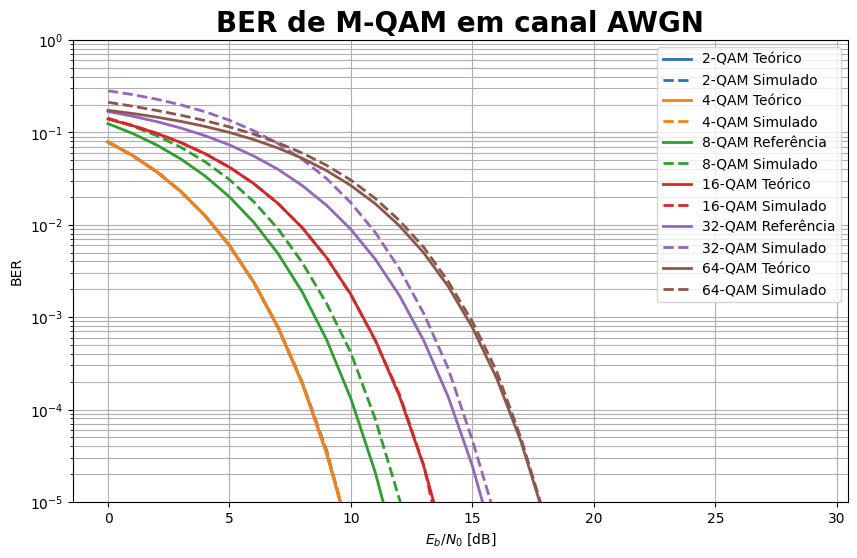

In [17]:
# ============================================================
#   Simulação de BER para 2-QAM e M-QAM em canal AWGN
#
#   Cada símbolo é representado por um vetor bidimensional:
#
#       s_i = [I_i, Q_i]
#
#   em que:
#       I_i -> componente em fase
#       Q_i -> componente em quadratura
#
#   O receptor utiliza o critério de máxima verossimilhança:
#   escolhe o ponto da constelação com menor distância
#   euclidiana em relação ao vetor recebido.
#
#   São considerados os seguintes casos:
#
#   1) 2-QAM:
#      Equivalente à modulação BPSK.
#
#   2) M-QAM quadrada:
#      k = log2(M) par
#      Exemplos: 4-QAM, 16-QAM e 64-QAM.
#
#   3) M-QAM não quadrada:
#      k = log2(M) ímpar
#      Exemplos: 8-QAM e 32-QAM cruzada.
# ============================================================

# ------------------------------------------------------------
# Inclui automaticamente a modulação 2-QAM na lista
# sem alterar a lista original utilizada em outras células.
# ------------------------------------------------------------

M_list_qam = sorted(set([2] + list(M_list)))

# -----------------------------
# Figura
# -----------------------------

plt.figure(figsize=(10, 6))

# -----------------------------
# Loop para cada M-QAM
# -----------------------------

for M in M_list_qam:
    # Quantidade de bits transportados por símbolo
    k = int(np.log2(M))

    # Número de símbolos simulados
    N_symbols = N_bits // k

    # Ajuste para garantir que a quantidade de bits
    # seja um múltiplo inteiro de k
    N_bits_real = N_symbols * k

    # Energia média por bit
    Eb = 1

    # Relação entre energia de símbolo e energia de bit:
    #
    # Es = k * Eb
    Es = k * Eb

    # Vetores para armazenar as curvas simulada e teórica
    ber_sim = np.zeros(itr)
    ber_theo = np.zeros(itr)

    modulation_name = nome_qam(M)

    # ---------------------------------------------------------
    # 1) Geração dos bits de informação
    # ---------------------------------------------------------

    tx_bits = np.random.randint(0, 2, N_bits_real)

    # Agrupamento dos bits em símbolos de k bits
    tx_bits_grouped = tx_bits.reshape(
        (N_symbols, k)
    )

    # Conversão dos grupos de bits para números decimais
    #
    # Cada valor decimal será utilizado como índice da LUT
    # que contém os pontos da constelação.
    tx_decimal = bits_to_decimal(tx_bits_grouped)

    # ---------------------------------------------------------
    # 2) Geração da constelação M-QAM
    # ---------------------------------------------------------

    if M == 2:

        # =====================================================
        # Caso 1: constelação 2-QAM
        # =====================================================
        #
        # A 2-QAM é equivalente à modulação BPSK.
        #
        # Existem dois pontos posicionados no eixo em fase:
        #
        # bit 0 -> [-1, 0]
        # bit 1 -> [ 1, 0]
        #
        # O eixo em quadratura permanece nulo.

        constellation = np.array([
            [-1, 0],  # bit 0
            [ 1, 0],  # bit 1
        ], dtype=float)

    elif k % 2 == 0:

        # =====================================================
        # Caso 2: constelação M-QAM quadrada
        # =====================================================
        #
        # Como k é par, os bits podem ser divididos igualmente
        # entre os eixos I e Q.
        #
        # Exemplos:
        #
        # 4-QAM  -> L = 2 níveis em cada eixo
        # 16-QAM -> L = 4 níveis em cada eixo
        # 64-QAM -> L = 8 níveis em cada eixo

        L = int(np.sqrt(M))

        # Geração dos níveis PAM igualmente espaçados
        #
        # Exemplo para 16-QAM:
        #
        # [-3, -1, 1, 3]
        niveis = np.arange(-(L - 1), L, 2)

        # Metade dos bits controla o eixo I
        # e metade controla o eixo Q
        bits_por_eixo = k // 2

        # Máscara binária utilizada para extrair
        # os bits menos significativos associados ao eixo Q
        mascara = (1 << bits_por_eixo) - 1

        # LUT da constelação:
        #
        # constellation[decimal] = [I, Q]
        constellation = np.zeros((M, 2), dtype=float)

        # Percorre todos os possíveis grupos de k bits
        for decimal in range(M):

            # Os bits mais significativos controlam I
            decimal_i = decimal >> bits_por_eixo

            # Os bits menos significativos controlam Q
            decimal_q = decimal & mascara

            # Conversão binário -> Gray independente
            # para cada eixo
            posicao_i = decimal_i ^ (decimal_i >> 1)
            posicao_q = decimal_q ^ (decimal_q >> 1)

            # Associação do grupo de bits às coordenadas [I, Q]
            constellation[decimal, 0] = niveis[posicao_i]
            constellation[decimal, 1] = niveis[::-1][posicao_q]

    elif M == 8:

        # =====================================================
        # Caso 3: constelação 8-QAM não quadrada
        # =====================================================

        constellation = np.array([
            [ 0,  3],  # 000
            [ 1,  1],  # 001
            [ 1, -1],  # 010
            [ 3,  0],  # 011
            [-1,  1],  # 100
            [-3,  0],  # 101
            [ 0, -3],  # 110
            [-1, -1],  # 111
        ], dtype=float)

    elif k >= 5:

        # =====================================================
        # Caso 4: M-QAM cruzada não quadrada
        # =====================================================
        #
        # Exemplos:
        #
        # 32-QAM  -> remove 1 ponto em cada canto
        # 128-QAM -> remove blocos 2 x 2 nos cantos
        # 512-QAM -> remove blocos 4 x 4 nos cantos

        # Tamanho dos blocos removidos em cada canto
        corner_size = 2 ** ((k - 5) // 2)

        # Quantidade de níveis em cada eixo antes
        # da remoção dos blocos dos cantos
        L = 6 * corner_size

        # Limite utilizado para identificar os pontos
        # pertencentes aos quatro cantos
        limite_canto = ((L - 1) - 2 * corner_size)

        # Níveis possíveis em cada eixo
        niveis = np.arange(-(L - 1), L, 2)

        constellation = []

        # Percorre inicialmente uma grade quadrada
        for q in niveis[::-1]:
            for i in niveis:

                # Remove os quatro blocos localizados nos cantos
                if abs(i) > limite_canto and abs(q) > limite_canto:
                    continue

                constellation.append([i, q])

        constellation = np.array(
            constellation,
            dtype=float
        )

    else:

        raise ValueError(
            f"Constelação M-QAM não definida para M = {M}."
        )

    # ---------------------------------------------------------
    # 3) Normalização da energia média da constelação
    # ---------------------------------------------------------
    #
    # Energia de cada símbolo:
    #
    # E_i = I_i² + Q_i²
    #
    # Energia média:
    #
    # Es_mean = média(E_i)

    Es_mean = np.mean(
        constellation[:, 0] ** 2 +
        constellation[:, 1] ** 2
    )

    # Ajusta a constelação para obter:
    #
    # Es = k * Eb
    constellation = constellation * np.sqrt(
        Es / Es_mean
    )

    # Seleciona os símbolos correspondentes
    # aos grupos de bits transmitidos
    tx_symbols = constellation[tx_decimal]

    # ---------------------------------------------------------
    # 4) Loop para cada valor de Eb/N0
    # ---------------------------------------------------------

    for n, EbN0dB in enumerate(EbN0dB_range):

        # Conversão de dB para escala linear
        EbN0 = 10 ** (
            EbN0dB / 10
        )

        # Como:
        #
        # Eb/N0 = Eb / N0
        #
        # então:
        #
        # N0 = Eb / (Eb/N0)
        N0 = Eb / EbN0

        # Desvio-padrão de cada componente real do AWGN
        noise_std = np.sqrt(
            N0 / 2
        )

        # Geração de ruído independente nos eixos I e Q
        noise = noise_std * np.random.randn(
            N_symbols,
            2
        )

        # Canal AWGN:
        #
        # x = s_i + n
        rx_symbols = tx_symbols + noise

        # -----------------------------------------------------
        # 5) Detector de máxima verossimilhança
        # -----------------------------------------------------
        #
        # Calcula a distância euclidiana quadrática entre cada
        # símbolo recebido e cada ponto possível:
        #
        # d² = (I_rx - I_i)² + (Q_rx - Q_i)²

        distances = np.zeros(
            (N_symbols, M)
        )

        for i in range(M):

            distances[:, i] = np.sum(
                (rx_symbols - constellation[i]) ** 2,
                axis=1
            )

        # Escolhe o índice do ponto mais próximo
        rx_decimal = np.argmin(
            distances,
            axis=1
        )

        # Conversão dos símbolos detectados para bits
        rx_bits_grouped = decimal_to_bits(
            rx_decimal,
            k
        )

        rx_bits = rx_bits_grouped.reshape(-1)

        # -----------------------------------------------------
        # 6) BER simulada
        # -----------------------------------------------------

        number_of_bit_errors = np.sum(
            tx_bits != rx_bits
        )

        ber_sim[n] = (
            number_of_bit_errors /
            N_bits_real
        )

        # -----------------------------------------------------
        # 7) BER teórica
        # -----------------------------------------------------

        if M == 2:

            # =================================================
            # 2-QAM equivalente à BPSK
            # =================================================
            #
            # BER = Q(sqrt(2 * Eb/N0))
            #
            # Utilizando a função erfc:
            #
            # BER = 0.5 * erfc(sqrt(Eb/N0))

            ber_theo[n] = 0.5 * erfc(
                np.sqrt(EbN0)
            )

        elif k % 2 == 0:

            # =================================================
            # M-QAM quadrada com mapeamento Gray
            # =================================================

            ber_theo[n] = (
                (2 / k) *
                (1 - 1 / np.sqrt(M)) *
                erfc(
                    np.sqrt(
                        3 * k * EbN0 /
                        (2 * (M - 1))
                    )
                )
            )

        else:

            # =================================================
            # M-QAM cruzada não quadrada
            # =================================================

            ber_theo[n] = (
                (2 / k) *
                (1 - 1 / np.sqrt(2 * M)) *
                erfc(
                    np.sqrt(
                        96 * k * EbN0 /
                        (62 * M - 64)
                    )
                )
            )

        print(
            f"{modulation_name:6s} | "
            f"Eb/N0 = {EbN0dB:2d} dB | "
            f"BER_sim = {ber_sim[n]:.6e} | "
            f"BER_teo = {ber_theo[n]:.6e}"
        )

    # Armazena os resultados para a comparação final
    ber_qam_theo_all[M] = ber_theo.copy()
    ber_qam_sim_all[M] = ber_sim.copy()

    # ---------------------------------------------------------
    # 8) Plot das curvas
    # ---------------------------------------------------------

    cor_M = cores_M[M]

    if M == 2:

        label_theo = "2-QAM Teórico"
        label_sim = "2-QAM Simulado"

    elif k % 2 == 0:

        label_theo = f"{M}-QAM Teórico"
        label_sim = f"{M}-QAM Simulado"

    else:

        label_theo = f"{M}-QAM Referência"
        label_sim = f"{M}-QAM Simulado"

    plt.semilogy(
        EbN0dB_range,
        ber_theo,
        "-",
        color=cor_M,
        linewidth=2,
        label=label_theo
    )

    plt.semilogy(
        EbN0dB_range,
        ber_sim,
        "--",
        color=cor_M,
        linewidth=2,
        label=label_sim
    )


# -----------------------------
# Configuração do gráfico
# -----------------------------

plt.grid(True, which="both")
plt.xlabel("$E_b/N_0$ [dB]")
plt.ylabel("BER")
plt.title(
    "BER de M-QAM em canal AWGN",
    fontsize=20,
    fontweight="bold"
)
plt.legend()
plt.ylim(1e-5, 1)

plt.show()

## **Simulação de BER para M-FSK**

BFSK   | Eb/N0 =  0 dB | BER_sim = 1.584533e-01 | BER_teo = 1.586553e-01
BFSK   | Eb/N0 =  1 dB | BER_sim = 1.309718e-01 | BER_teo = 1.309273e-01
BFSK   | Eb/N0 =  2 dB | BER_sim = 1.038925e-01 | BER_teo = 1.040286e-01
BFSK   | Eb/N0 =  3 dB | BER_sim = 7.877840e-02 | BER_teo = 7.889587e-02
BFSK   | Eb/N0 =  4 dB | BER_sim = 5.650710e-02 | BER_teo = 5.649530e-02
BFSK   | Eb/N0 =  5 dB | BER_sim = 3.769890e-02 | BER_teo = 3.767899e-02
BFSK   | Eb/N0 =  6 dB | BER_sim = 2.295000e-02 | BER_teo = 2.300714e-02
BFSK   | Eb/N0 =  7 dB | BER_sim = 1.259170e-02 | BER_teo = 1.258703e-02
BFSK   | Eb/N0 =  8 dB | BER_sim = 6.019200e-03 | BER_teo = 6.004386e-03
BFSK   | Eb/N0 =  9 dB | BER_sim = 2.426000e-03 | BER_teo = 2.413310e-03
BFSK   | Eb/N0 = 10 dB | BER_sim = 7.826000e-04 | BER_teo = 7.827011e-04
BFSK   | Eb/N0 = 11 dB | BER_sim = 2.003000e-04 | BER_teo = 1.939855e-04
BFSK   | Eb/N0 = 12 dB | BER_sim = 3.240000e-05 | BER_teo = 3.430262e-05
BFSK   | Eb/N0 = 13 dB | BER_sim = 4.700000e-06 | B

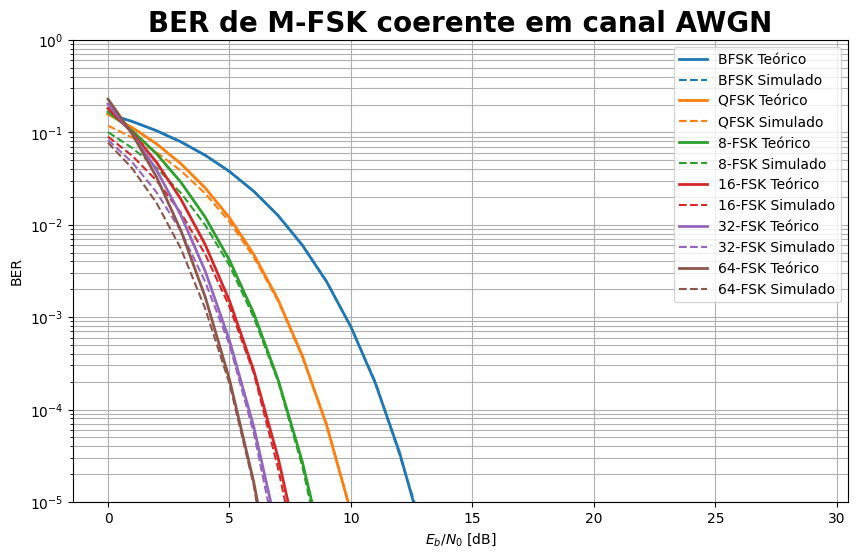

In [18]:
# ============================================================
#   Simulação de BER para M-FSK ortogonal coerente
#   em canal AWGN
#
#   Cada símbolo ocupa uma dimensão distinta no espaço
#   de sinais.
#
#   Para uma M-FSK ortogonal, o espaço de sinais possui
#   dimensão M.
#
#   Exemplo para 4-FSK:
#
#   s_0 = [sqrt(Es), 0,        0,        0       ]
#   s_1 = [0,        sqrt(Es), 0,        0       ]
#   s_2 = [0,        0,        sqrt(Es), 0       ]
#   s_3 = [0,        0,        0,        sqrt(Es)]
#
#   A detecção é realizada por máxima verossimilhança:
#   escolhe-se o símbolo com menor distância euclidiana.
# ============================================================

# -----------------------------
# Figura
# -----------------------------

plt.figure(figsize=(10, 6))

# -----------------------------
# Loop para cada M-FSK
# -----------------------------

for M in M_list:

    # Quantidade de bits transportados por símbolo
    k = int(np.log2(M))

    # Número de símbolos simulados
    N_symbols = N_bits // k

    # Ajuste para múltiplo inteiro de k
    N_bits_real = N_symbols * k

    # Vetores para armazenar as curvas
    ber_sim = np.zeros(itr)

    ber_theo = np.zeros(itr)

    # Nome utilizado no gráfico e no terminal
    modulation_name = nome_fsk(M)

    # ---------------------------------------------------------
    # 1) Geração dos bits de informação
    # ---------------------------------------------------------

    tx_bits = np.random.randint(0, 2, N_bits_real)

    # Agrupamento dos bits em símbolos de k bits
    tx_bits_grouped = tx_bits.reshape((N_symbols, k))

    # Conversão dos símbolos binários para decimal
    tx_decimal = bits_to_decimal(tx_bits_grouped)

    # ---------------------------------------------------------
    # 2) Constelação ortogonal M-FSK
    # ---------------------------------------------------------

    # Energia média por bit
    Eb = 1

    # Energia por símbolo:
    #
    # Es = k * Eb
    Es = k * Eb

    # A matriz identidade gera símbolos ortogonais.
    #
    # Cada linha representa um símbolo M-FSK possível.
    #
    # A multiplicação por sqrt(Es) garante que cada símbolo
    # tenha energia Es.
    constellation = (np.sqrt(Es) * np.eye(M))

    # Seleciona os símbolos correspondentes
    # aos grupos de bits transmitidos
    tx_symbols = constellation[
        tx_decimal
    ]

    # ---------------------------------------------------------
    # 3) Loop para cada valor de Eb/N0
    # ---------------------------------------------------------

    for n, EbN0dB in enumerate(EbN0dB_range):

        # Conversão de dB para escala linear
        EbN0 = 10 ** (EbN0dB / 10)

        # Cálculo da densidade espectral de potência do ruído
        N0 = Eb / EbN0

        # Desvio-padrão de cada componente real do AWGN
        noise_std = np.sqrt(N0 / 2)

        # O ruído possui uma componente independente
        # para cada uma das M dimensões
        noise = noise_std * np.random.randn(N_symbols, M)

        # Canal AWGN:
        #
        # x = s_i + n
        rx_symbols = tx_symbols + noise

        # -----------------------------------------------------
        # 4) Detector de máxima verossimilhança
        # -----------------------------------------------------
        #
        # O receptor calcula a distância euclidiana quadrática
        # entre o vetor recebido e cada símbolo possível.
        #
        # Em seguida, escolhe o símbolo mais próximo.

        distances = np.zeros((N_symbols, M))

        for i in range(M):

            distances[:, i] = np.sum((rx_symbols - constellation[i]) ** 2, axis=1)

        rx_decimal = np.argmin(distances, axis=1)

        # -----------------------------------------------------
        # 5) Conversão dos símbolos detectados para bits
        # -----------------------------------------------------

        rx_bits_grouped = decimal_to_bits(rx_decimal, k)

        rx_bits = rx_bits_grouped.reshape(-1)

        # -----------------------------------------------------
        # 6) BER simulada
        # -----------------------------------------------------

        bit_errors = np.sum(tx_bits != rx_bits)

        ber_sim[n] = (bit_errors / N_bits_real)

        # -----------------------------------------------------
        # 7) BER teórica aproximada
        # -----------------------------------------------------
        #
        # Probabilidade de erro de símbolo:
        #
        # Ps ≈ ((M - 1) * 0.5 * erfc(np.sqrt(k * EbN0 /2)))
        #
        # Para M-FSK ortogonal:
        #
        # BER = [M / (2*(M - 1))] * Ps

        Ps = ((M - 1) * 0.5 * erfc(np.sqrt(k * EbN0 /2)))

        ber_theo[n] = (M / (2 * (M - 1))) * Ps

        print(
            f"{modulation_name:6s} | "
            f"Eb/N0 = {EbN0dB:2d} dB | "
            f"BER_sim = {ber_sim[n]:.6e} | "
            f"BER_teo = {ber_theo[n]:.6e}"
        )

    # Armazena os resultados para a comparação final
    ber_fsk_theo_all[M] = ber_theo.copy()

    ber_fsk_sim_all[M] = ber_sim.copy()

    # ---------------------------------------------------------
    # 8) Plot das curvas
    # ---------------------------------------------------------

    cor_M = cores_M[M]

    plt.semilogy(
        EbN0dB_range,
        ber_theo,
        "-",
        color=cor_M,
        linewidth=2,
        label=f"{modulation_name} Teórico"
    )

    plt.semilogy(
        EbN0dB_range,
        ber_sim,
        linestyle="--",
        color=cor_M,
        label=f"{modulation_name} Simulado"
    )

# -----------------------------
# Configuração do gráfico
# -----------------------------

plt.grid(True, which="both")
plt.xlabel("$E_b/N_0$ [dB]")
plt.ylabel("BER")
plt.title("BER de M-FSK coerente em canal AWGN", fontsize=20, fontweight="bold")
plt.legend()
plt.ylim(1e-5, 1)
plt.show()

## **Comparação dos resultados obtidos**

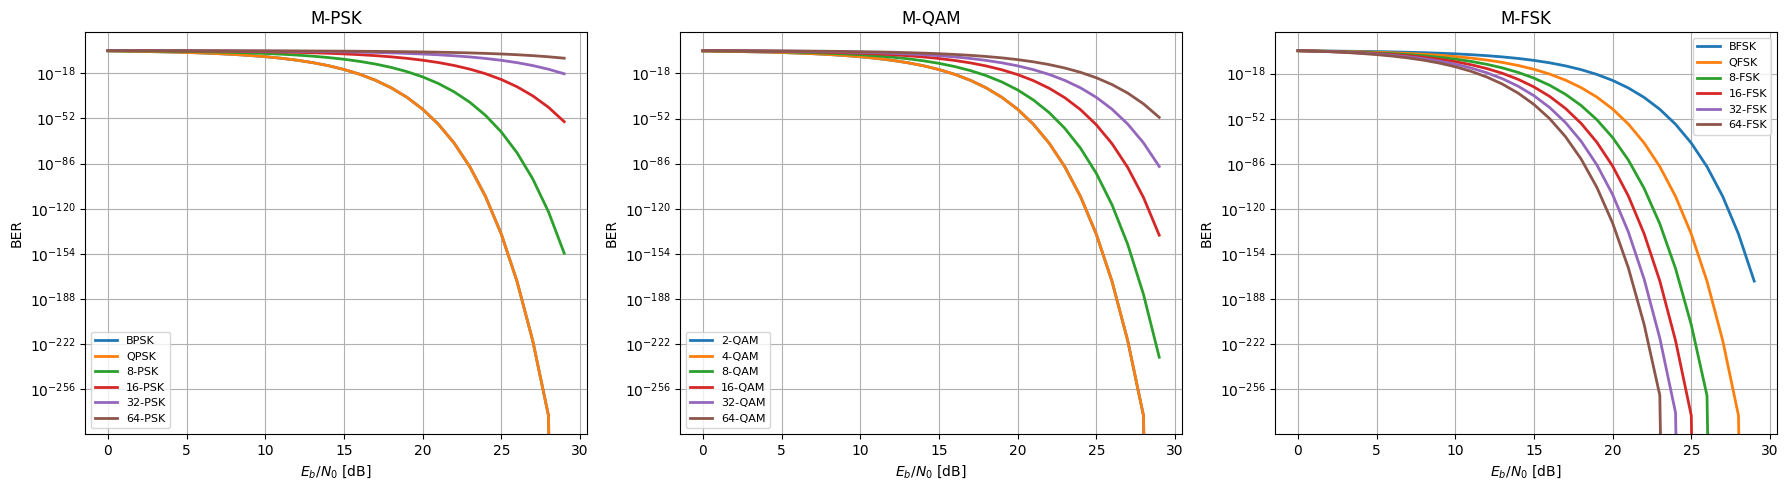

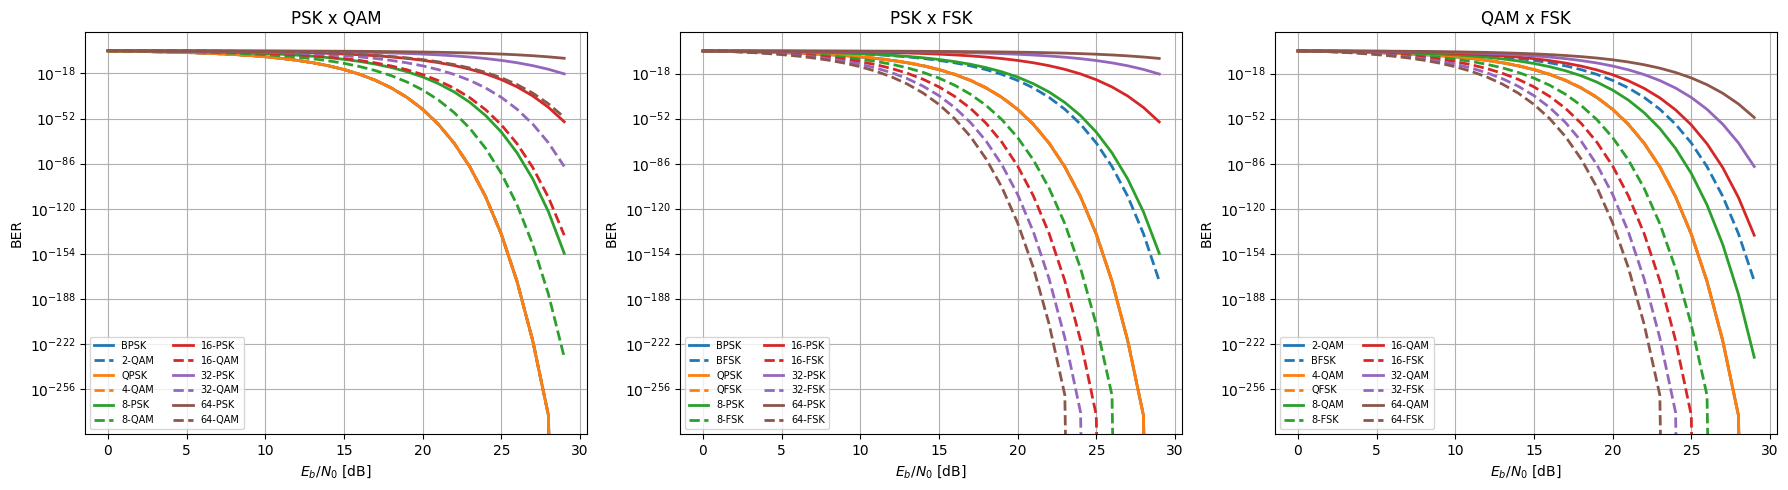

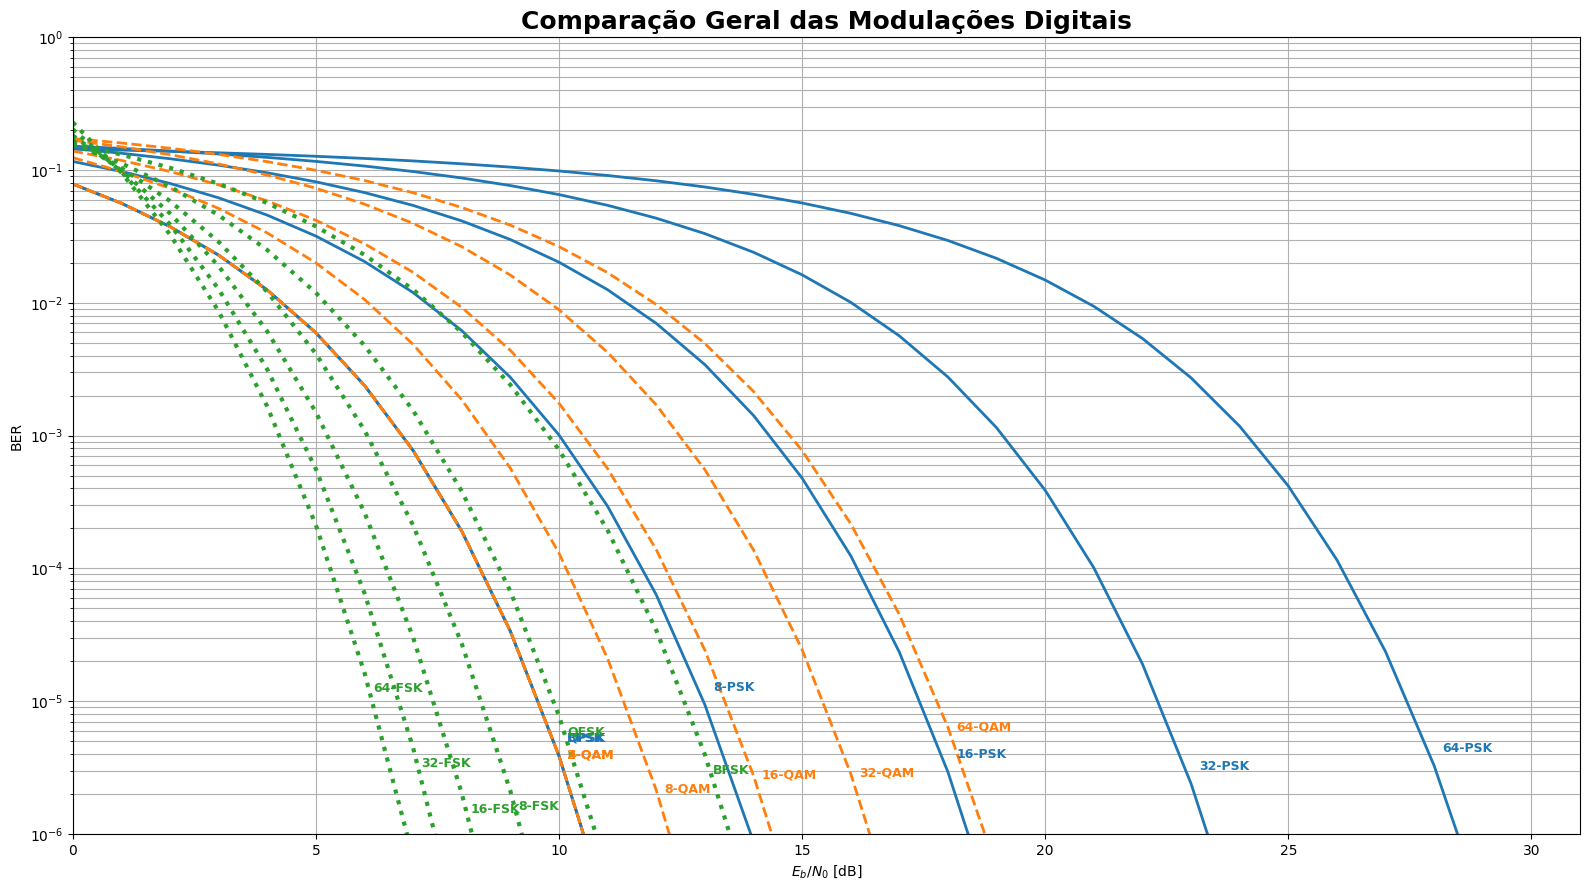

In [19]:
# ============================================================
#   Comparação das curvas teóricas de BER
#
#   Dicionários utilizados:
#
#   ber_psk_theo_all[M]
#   ber_qam_theo_all[M]
#   ber_fsk_theo_all[M]
# ============================================================

# ------------------------------------------------------------
# Ordens disponíveis em cada família
# ------------------------------------------------------------

M_list_psk = sorted(ber_psk_theo_all.keys())
M_list_qam = sorted(ber_qam_theo_all.keys())
M_list_fsk = sorted(ber_fsk_theo_all.keys())

# ============================================================
# Figura 1 - Gráficos individuais por família de modulação
# ============================================================

fig, ax = plt.subplots(
    1,
    3,
    figsize=(18, 5)
)

# ------------------------------------------------------------
# M-PSK
# ------------------------------------------------------------

for M in M_list_psk:
    ax[0].semilogy(
        EbN0dB_range,
        ber_psk_theo_all[M],
        color=cores_M[M],
        linewidth=2,
        label=nome_psk(M)
    )

ax[0].grid(True, which="both")
ax[0].set_title("M-PSK")
ax[0].set_xlabel("$E_b/N_0$ [dB]")
ax[0].set_ylabel("BER")
ax[0].legend(fontsize=8)

# ------------------------------------------------------------
# M-QAM
# ------------------------------------------------------------

for M in M_list_qam:
    ax[1].semilogy(
        EbN0dB_range,
        ber_qam_theo_all[M],
        color=cores_M[M],
        linewidth=2,
        label=nome_qam(M)
    )

ax[1].grid(True, which="both")
ax[1].set_title("M-QAM")
ax[1].set_xlabel("$E_b/N_0$ [dB]")
ax[1].set_ylabel("BER")
ax[1].legend(fontsize=8)

# ------------------------------------------------------------
# M-FSK
# ------------------------------------------------------------

for M in M_list_fsk:
    ax[2].semilogy(
        EbN0dB_range,
        ber_fsk_theo_all[M],
        color=cores_M[M],
        linewidth=2,
        label=nome_fsk(M)
    )

ax[2].grid(True, which="both")
ax[2].set_title("M-FSK")
ax[2].set_xlabel("$E_b/N_0$ [dB]")
ax[2].set_ylabel("BER")
ax[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

# ============================================================
# Figura 2 - Comparações duas a duas
# ============================================================
#
# A cor identifica a quantidade de símbolos:
#
# M = 2, 4, 8, 16, 32, 64...
#
# O estilo da linha identifica a família:
#
# linha contínua  -> primeira família
# linha tracejada -> segunda família
# ============================================================

fig, ax = plt.subplots(
    1,
    3,
    figsize=(18, 5)
)

# ------------------------------------------------------------
# PSK x QAM
# ------------------------------------------------------------

M_psk_qam = sorted(
    set(M_list_psk) &
    set(M_list_qam)
)

for M in M_psk_qam:

    ax[0].semilogy(
        EbN0dB_range,
        ber_psk_theo_all[M],
        "-",
        color=cores_M[M],
        linewidth=2,
        label=nome_psk(M)
    )

    ax[0].semilogy(
        EbN0dB_range,
        ber_qam_theo_all[M],
        "--",
        color=cores_M[M],
        linewidth=2,
        label=nome_qam(M)
    )

ax[0].grid(True, which="both")
ax[0].set_title("PSK x QAM")
ax[0].set_xlabel("$E_b/N_0$ [dB]")
ax[0].set_ylabel("BER")
ax[0].legend(fontsize=7, ncol=2)

# ------------------------------------------------------------
# PSK x FSK
# ------------------------------------------------------------

M_psk_fsk = sorted(
    set(M_list_psk) &
    set(M_list_fsk)
)

for M in M_psk_fsk:
    ax[1].semilogy(
        EbN0dB_range,
        ber_psk_theo_all[M],
        "-",
        color=cores_M[M],
        linewidth=2,
        label=nome_psk(M)
    )

    ax[1].semilogy(
        EbN0dB_range,
        ber_fsk_theo_all[M],
        "--",
        color=cores_M[M],
        linewidth=2,
        label=nome_fsk(M)
    )

ax[1].grid(True, which="both")
ax[1].set_title("PSK x FSK")
ax[1].set_xlabel("$E_b/N_0$ [dB]")
ax[1].set_ylabel("BER")
ax[1].legend(fontsize=7, ncol=2)

# ------------------------------------------------------------
# QAM x FSK
# ------------------------------------------------------------

M_qam_fsk = sorted(
    set(M_list_qam) &
    set(M_list_fsk)
)

for M in M_qam_fsk:
    ax[2].semilogy(
        EbN0dB_range,
        ber_qam_theo_all[M],
        "-",
        color=cores_M[M],
        linewidth=2,
        label=nome_qam(M)
    )

    ax[2].semilogy(
        EbN0dB_range,
        ber_fsk_theo_all[M],
        "--",
        color=cores_M[M],
        linewidth=2,
        label=nome_fsk(M)
    )

ax[2].grid(True, which="both")
ax[2].set_title("QAM x FSK")
ax[2].set_xlabel("$E_b/N_0$ [dB]")
ax[2].set_ylabel("BER")
ax[2].legend(fontsize=7, ncol=2)

plt.tight_layout()
plt.show()

# ============================================================
# Figura 3 - Comparação geral
# ============================================================
#
# Cores:
#
# azul    -> M-PSK
# laranja -> M-QAM
# verde   -> M-FSK
#
# Estilos:
#
# linha contínua  -> M-PSK
# linha tracejada -> M-QAM
# linha pontilhada -> M-FSK
#
# Não é utilizada legenda. O nome de cada modulação aparece
# diretamente sobre sua respectiva curva.
# ============================================================

plt.figure(figsize=(16, 9))

ax = plt.gca()

limite_inferior = 1e-6
limite_superior = 1

# ------------------------------------------------------------
# Função auxiliar para adicionar o nome sobre cada curva
# ------------------------------------------------------------

# Adiciona um rótulo próximo ao último ponto visível da curva
def adicionar_rotulo_na_curva(eixo, x, y, texto, cor, deslocamento_x=6, deslocamento_y=6):
    y = np.asarray(y)

    indices_validos = np.where(
        np.isfinite(y) &
        (y >= limite_inferior) &
        (y <= limite_superior)
    )[0]

    if len(indices_validos) == 0:
        return

    indice = indices_validos[-1]

    eixo.annotate(
        texto,
        xy=(x[indice], y[indice]),
        xytext=(deslocamento_x, deslocamento_y),
        textcoords="offset points",
        color=cor,
        fontsize=9,
        fontweight="bold"
    )

# ------------------------------------------------------------
# M-PSK
# ------------------------------------------------------------

for M in M_list_psk:
    curva_psk = ber_psk_theo_all[M]

    ax.semilogy(
        EbN0dB_range,
        curva_psk,
        "-",
        color="tab:blue",
        linewidth=2
    )

    adicionar_rotulo_na_curva(
        eixo=ax,
        x=EbN0dB_range,
        y=curva_psk,
        texto=nome_psk(M),
        cor="tab:blue",
        deslocamento_y=10
    )


# ------------------------------------------------------------
# M-QAM
# ------------------------------------------------------------

for M in M_list_qam:
    curva_qam = ber_qam_theo_all[M]

    ax.semilogy(
        EbN0dB_range,
        curva_qam,
        "--",
        color="tab:orange",
        linewidth=2
    )

    adicionar_rotulo_na_curva(
        eixo=ax,
        x=EbN0dB_range,
        y=curva_qam,
        texto=nome_qam(M),
        cor="tab:orange",
        deslocamento_y=-2
    )

# ------------------------------------------------------------
# M-FSK
# ------------------------------------------------------------

for M in M_list_fsk:
    curva_fsk = ber_fsk_theo_all[M]

    ax.semilogy(
        EbN0dB_range,
        curva_fsk,
        ":",
        color="tab:green",
        linewidth=3
    )

    adicionar_rotulo_na_curva(
        eixo=ax,
        x=EbN0dB_range,
        y=curva_fsk,
        texto=nome_fsk(M),
        cor="tab:green",
        deslocamento_y=-14
    )

# ------------------------------------------------------------
# Configuração do gráfico
# ------------------------------------------------------------

ax.grid(True, which="both")

ax.set_xlabel(
    "$E_b/N_0$ [dB]"
)

ax.set_ylabel(
    "BER"
)

ax.set_title(
    "Comparação Geral das Modulações Digitais",
    fontsize=18,
    fontweight="bold"
)

ax.set_ylim(
    limite_inferior,
    limite_superior
)

# Espaço adicional à direita para exibir os rótulos
ax.set_xlim(
    EbN0dB_range[0],
    EbN0dB_range[-1] + 2
)

plt.tight_layout()
plt.show()

## **Comparação entre as modulações M-PSK, M-QAM e M-FSK**

Os gráficos apresentam a taxa de erro de bit, denominada BER (*Bit Error Rate*), em função da relação entre a energia média por bit e a densidade espectral de potência do ruído:

$$
\frac{E_b}{N_0}
$$

A análise considera um canal AWGN (*Additive White Gaussian Noise*) e receptores com detecção coerente. Quanto maior o valor de $E_b/N_0$, menor tende a ser a influência do ruído sobre o sinal recebido e, consequentemente, menor é a BER.

Nas figuras das simulações, as linhas contínuas representam os valores teóricos e as linhas tracejadas representam os resultados obtidos por simulação. A proximidade entre essas curvas mostra que o comportamento observado numericamente é compatível com as expressões matemáticas utilizadas.

---

### **Ordem da modulação e quantidade de bits por símbolo**

Em uma modulação digital com (M) símbolos, cada símbolo transporta k bits:

$$
k = \log_2(M)
$$

Portanto, o aumento da ordem (M) permite transmitir uma quantidade maior de bits em cada intervalo de símbolo.

| Ordem da modulação (M) | Quantidade de bits por símbolo (k) |
| ---------------------: | ---------------------------------: |
|                      2 |                                  1 |
|                      4 |                                  2 |
|                      8 |                                  3 |
|                     16 |                                  4 |
|                     32 |                                  5 |
|                     64 |                                  6 |

É importante diferenciar a ordem da modulação da quantidade de bits. Por exemplo, uma modulação 64-QAM possui (64) símbolos possíveis, mas cada símbolo representa n bits:

$$
n = \log_2(64)=6
$$

O efeito causado pelo aumento de (M) não é igual para todas as famílias. Nas modulações M-PSK e M-QAM, o aumento de (M) melhora a eficiência espectral, mas reduz a robustez ao ruído. Na M-FSK ortogonal, ocorre o comportamento oposto em termos de eficiência de potência: o aumento de (M) pode reduzir a BER, mas provoca maior ocupação de banda.

---

## **Modulação M-PSK**

Na modulação M-PSK (*M-ary Phase Shift Keying*), os símbolos possuem a mesma energia e são diferenciados por suas fases. A constelação é composta por (M) pontos igualmente espaçados sobre uma circunferência.

A separação angular entre símbolos adjacentes é dada por:

$$
\Delta\theta = \frac{2\pi}{M}
$$

Quando (M) aumenta, a separação angular diminui. Com isso, os símbolos vizinhos ficam mais próximos no espaço de sinais e o receptor passa a ter maior dificuldade para distingui-los na presença de ruído.

Para (M >= 4), utilizando mapeamento Gray e considerando valores suficientemente elevados de (E_b/N_0), a BER pode ser aproximada por:

$$
\text{BER} \approx \frac{1}{\log_2(M)}\operatorname{erfc}\left[\sqrt{\log_2(M)\frac{E_b}{N_0}}\sin\left(\frac{\pi}{M}\right)\right]
$$

### **Interpretação das curvas M-PSK**

| Modulação | Bits por símbolo | Interpretação da curva                                                                                          |
| --------- | ---------------: | --------------------------------------------------------------------------------------------------------------- |
| BPSK      | 1                | Apresenta elevada robustez ao ruído.                                                                            |
| QPSK      | 2                | Possui a mesma BER da BPSK para um mesmo (E_b/N_0), mas transmite o dobro de bits por símbolo.                  |
| 8-PSK     | 3                | Apresenta BER maior que a QPSK devido à redução da distância angular entre os símbolos.                         |
| 16-PSK    | 4                | Exige maior (E_b/N_0) para atingir uma mesma BER.                                                               |
| 32-PSK    | 5                | Possui maior sensibilidade ao ruído devido à proximidade entre os pontos da constelação.                        |
| 64-PSK    | 6                | É a menos robusta entre as ordens analisadas, pois apresenta a menor separação angular entre símbolos vizinhos. |

A BPSK e a QPSK apresentam curvas coincidentes no gráfico de BER em função de $E_b/N_0$. Entretanto, a QPSK possui maior eficiência espectral, pois transmite dois bits por símbolo.

A partir da 8-PSK, o aumento da ordem degrada progressivamente a BER. Para um mesmo valor de $E_b/N_0$, observa-se aproximadamente:

$$
\text{BER}_{64\text{-PSK}}>\text{BER}_{32\text{-PSK}}>\text{BER}_{16\text{-PSK}}>\text{BER}_{8\text{-PSK}}>\text{BER}_{\text{QPSK}}
$$

Considerando como banda ocupada a largura do lobo principal do espectro, a eficiência espectral da M-PSK é:

$$
\mathcal{S}_{\text{M-PSK}} = \frac{\log_2(M)}{2}\quad \text{bit/s/Hz}
$$

Assim, aumentar (M) melhora a eficiência espectral, mas reduz a eficiência de potência.

---

## **Modulação M-QAM**

Na modulação M-QAM (*M-ary Quadrature Amplitude Modulation*), os símbolos são representados por diferentes combinações das componentes em fase e em quadratura:

$$
\mathbf{s}_i =[I_i,Q_i]
$$

Diferentemente da M-PSK, os símbolos da M-QAM não possuem necessariamente a mesma energia. A modulação utiliza simultaneamente variações de amplitude e fase.

As constelações podem ser classificadas em:

* constelações quadradas, como 4-QAM, 16-QAM e 64-QAM;
* constelações não quadradas, como 8-QAM;
* constelações cruzadas, como 32-QAM.

Ao aumentar (M), uma quantidade maior de pontos precisa ser distribuída no plano $I/Q$. Mantendo a energia média constante, a distância entre símbolos vizinhos diminui. Portanto, a BER aumenta.

### **Interpretação das curvas M-QAM**

| Modulação | Bits por símbolo | Interpretação da curva                                                                                                           |
| --------- | ---------------: | -------------------------------------------------------------------------------------------------------------------------------- |
| 2-QAM     |                1 | Foi incluída na simulação como referência binária. Seu comportamento é equivalente ao de uma sinalização antipodal, como a BPSK. |
| 4-QAM     |                2 | É um caso especial da M-QAM quadrada e possui o mesmo desempenho da QPSK.                                                        |
| 8-QAM     |                3 | Apresenta BER maior que a 4-QAM. Como a constelação não é quadrada, a curva teórica deve ser interpretada como referência.       |
| 16-QAM    |                4 | Possui menor robustez ao ruído que a 8-QAM, mas permite transmitir mais bits por símbolo.                                        |
| 32-QAM    |                5 | Apresenta degradação adicional da BER. A curva teórica é uma referência para a constelação cruzada.                              |
| 64-QAM    |                6 | Possui a maior BER da família entre as ordens analisadas, mas transmite seis bits por símbolo.                                   |

No caso da 4-QAM, a expressão da probabilidade de erro se reduz àquela obtida para a QPSK. Por isso, as duas modulações possuem curvas coincidentes.

Para as ordens analisadas, observa-se aproximadamente:

$$
\text{BER}_{64\text{-QAM}}>\text{BER}_{32\text{-QAM}}>\text{BER}_{16\text{-QAM}}>\text{BER}_{8\text{-QAM}}>\text{BER}_{4\text{-QAM}}
$$

A densidade espectral de potência e a eficiência espectral da M-QAM são iguais às da M-PSK. Portanto:

$$
\mathcal{S}_{\text{M-QAM}}=\frac{\log_2(M)}{2}\quad\text{bit/s/Hz}
$$

Entretanto, para $M \geq 8$, a M-QAM apresenta menor probabilidade de erro que a M-PSK correspondente. Isso ocorre porque a disposição dos pontos no plano $I/Q$ permite utilizar o espaço de sinais de forma mais eficiente.

Um caso particular é a comparação entre 8-QAM e 8-PSK. Embora a 8-QAM possa apresentar desempenho ligeiramente superior, a 8-PSK é frequentemente mais conveniente na prática porque todos os seus símbolos possuem a mesma energia, simplificando o receptor.

---

## **Modulação M-FSK**

Na modulação M-FSK (*M-ary Frequency Shift Keying*), cada símbolo é associado a uma frequência diferente.

Considerando sinais ortogonais, os símbolos satisfazem:

$$
\int_0^T s_i(t)s_j(t)dt=0,\qquad i \neq j
$$

Nas modulações M-FSK coerentes com símbolos equiprováveis, a distância euclidiana entre qualquer par de símbolos é a mesma. Por isso, diferentemente da M-PSK e da M-QAM, o mapeamento entre símbolos e palavras binárias não altera a relação entre a probabilidade de erro de símbolo e a BER.

Para valores suficientemente elevados de (E_b/N_0), a expressão da BER é obtida por aproximação a partir do limitante de união.

### **Interpretação das curvas M-FSK**

| Modulação | Bits por símbolo | Interpretação da curva                                                                      |
| --------- | ---------------: | ------------------------------------------------------------------------------------------- |
| BFSK      |                1 | Apresenta a maior BER entre as curvas M-FSK analisadas.                                     |
| QFSK      |                2 | Possui BER menor que a BFSK para um mesmo (E_b/N_0).                                        |
| 8-FSK     |                3 | A BER diminui com o aumento da ordem da modulação.                                          |
| 16-FSK    |                4 | Apresenta maior eficiência de potência que a 8-FSK.                                         |
| 32-FSK    |                5 | Atinge valores baixos de BER com menor (E_b/N_0).                                           |
| 64-FSK    |                6 | Apresenta a menor BER entre as curvas M-FSK analisadas, mas exige a maior largura de banda. |

Nas curvas obtidas, observa-se aproximadamente:

$$
\text{BER}_{64\text{-FSK}}<\text{BER}_{32\text{-FSK}}<\text{BER}_{16\text{-FSK}}<\text{BER}_{8\text{-FSK}}<\text{BER}_{\text{QFSK}}<\text{BER}_{\text{BFSK}}
$$

Esse comportamento é oposto ao observado nas famílias M-PSK e M-QAM. Na M-FSK ortogonal, aumentar (M) melhora a eficiência de potência.

Entretanto, essa melhoria possui um custo significativo: o aumento da ordem exige uma quantidade maior de frequências ortogonais. Consequentemente, a largura de banda ocupada também aumenta.

Considerando uma separação de (1/T) entre os tons, a largura do lobo principal é:

$$
B = \frac{M+1}{T}
$$

Portanto, a eficiência espectral é:

$$
\mathcal{S}_{\text{M-FSK}} = \frac{\log_2(M)}{M+1} \quad \text{bit/s/Hz}
$$

Assim, a eficiência espectral da M-FSK diminui quando $M$ aumenta. Por esse motivo, a M-FSK é considerada pouco eficiente em termos de ocupação de banda.

---

## **Comparação entre M-PSK e M-QAM**

A comparação entre as curvas M-PSK e M-QAM mostra que:

* QPSK e 4-QAM apresentam o mesmo desempenho;
* a M-PSK possui símbolos com a mesma energia;
* a M-QAM utiliza diferentes combinações de amplitude e fase;
* para $M \geq 8$, a M-QAM tende a apresentar BER inferior à M-PSK correspondente;
* a M-QAM e a M-PSK possuem a mesma eficiência espectral.

Assim, para ordens elevadas, a M-QAM oferece melhor compromisso entre BER e eficiência espectral. Entretanto, sua implementação exige maior cuidado, pois os símbolos não possuem necessariamente a mesma energia.

---

## **Comparação entre M-PSK e M-FSK**

Quando a ordem $M$ aumenta, as famílias apresentam comportamentos opostos:

| Família | Efeito do aumento de $M$ sobre a BER | Efeito sobre a largura de banda |
| ------- | ------------------------------------ | ------------------------------- |
| M-PSK   | A BER aumenta                        | A eficiência espectral melhora  |
| M-FSK   | A BER diminui                        | A eficiência espectral piora    |

Na M-PSK, o aumento de $M$ reduz a distância angular entre os símbolos. Na M-FSK, os símbolos permanecem ortogonais, mas o número de tons utilizados aumenta.

Portanto, a M-PSK é mais adequada quando a limitação de banda é prioritária. A M-FSK pode ser mais adequada quando há maior disponibilidade de espectro e a economia de potência é mais importante.

---

## **Comparação entre M-QAM e M-FSK**

A comparação entre M-QAM e M-FSK evidencia uma relação de compromisso:

| Família | Principal vantagem           | Principal desvantagem                        |
| ------- | ---------------------------- | -------------------------------------------- |
| M-QAM   | Elevada eficiência espectral | A BER aumenta quando $M$ cresce              |
| M-FSK   | Boa eficiência de potência   | A largura de banda cresce quando $M$ aumenta |

A M-QAM é adequada para sistemas que precisam transmitir taxas elevadas em uma largura de banda limitada. A M-FSK é adequada quando a largura de banda disponível é maior e se deseja reduzir a potência necessária para atingir determinada BER.

---

## **Síntese dos resultados**

| Família | Efeito do aumento da quantidade de bits por símbolo | Interpretação                                                                  |
| ------- | --------------------------------------------------- | ------------------------------------------------------------------------------ |
| M-PSK   | A BER aumenta                                       | Os símbolos ficam mais próximos angularmente.                                  |
| M-QAM   | A BER aumenta                                       | Os pontos ficam mais próximos no plano $I/Q$.                                  |
| M-FSK   | A BER diminui                                       | Os símbolos ortogonais mantêm separação adequada, mas exigem mais frequências. |

Portanto, não existe uma única modulação ideal para todos os sistemas. A escolha depende das limitações de potência, largura de banda disponível, complexidade do receptor e BER desejada.

---

## **Observação sobre as curvas teóricas**

As expressões utilizadas nas simulações devem ser interpretadas de acordo com as aproximações adotadas:

* a expressão da BER da M-PSK com mapeamento Gray é uma aproximação adequada para valores elevados de $E_b/N_0$;
* a BER da M-QAM quadrada considera mapeamento Gray entre símbolos vizinhos;
* para constelações M-QAM não quadradas ou cruzadas, a curva deve ser interpretada como uma referência;
* a expressão da BER da M-FSK coerente é obtida a partir do limitante de união e se aproxima melhor do comportamento real para valores elevados de $E_b/N_0$.

Valores extremamente baixos de BER, como $10^{-20}$ ou $10^{-50}$, são úteis para a comparação matemática entre as curvas teóricas. Entretanto, sua validação direta por simulação de Monte Carlo exigiria a transmissão de uma quantidade muito elevada de bits.
